In [2]:
# IDF Results Visualization Notebook
# Visualize IDF curve results across scenarios and cities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
from pathlib import Path

# Set seaborn style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Configuration
BASE_PATH = "/home/scratch/idf_curves"
VERSION_TAG = "v1" # corresponds to if we have multiple runs/vers of the IDF data, not versioning the figures

# Scenarios and their year ranges
SCENARIOS = {
    'HIST': '1990-2005',
    'MID4p5': '2040-2055', 
    'MID8p5': '2040-2055',
    'EOC4p5': '2085-2100',
    'EOC8p5': '2085-2100'
}

# Cities
CITIES = ['albany', 'amarillo', 'grand_junction', 'minneapolis', 
          'nashville', 'phoenix', 'seattle', 'tallahassee']

# Return periods and durations of interest
RETURN_PERIODS = [2, 5, 10, 25, 50, 100]
DURATIONS = ['15min', '1hr', '24hr']  # Key durations for paper

print("Loading IDF data and calculating departures...")


Loading IDF data and calculating departures...


In [3]:
# Load data and calculate departures
def load_idf_data():
    """Load IDF data for all scenarios and cities"""
    data = {}
    
    for scenario, year_range in SCENARIOS.items():
        data[scenario] = {}
        
        for city in CITIES:
            file_path = f"{BASE_PATH}/{scenario}/{city}/idf_curves_{scenario}_{year_range}_{city}_{VERSION_TAG}.nc"
            
            if os.path.exists(file_path):
                try:
                    ds = xr.open_dataset(file_path)
                    data[scenario][city] = ds
                    print(f" Loaded {scenario}/{city}")
                except Exception as e:
                    print(f" Error loading {scenario}/{city}: {e}")
            else:
                print(f" File not found: {scenario}/{city}")
    
    return data

def extract_intensities(data, duration='1hr'):
    """Extract (median) intensity values for a specific duration"""
    results = {}
    
    for scenario in data:
        results[scenario] = {}
        
        for city in data[scenario]:
            ds = data[scenario][city]
            
            # Find duration index
            duration_labels = ds.duration_label.values
            if duration in duration_labels:
                dur_idx = list(duration_labels).index(duration)
                
                # Extract "ensemble" mean or median intensities for all return periods ("ensemble" is a poor term, but stuck with itifrom the initial data)
                #intensities = ds.ensemble_mean[:, dur_idx].values
                intensities = ds.ensemble_median[:, dur_idx].values
                
                # Create dictionary with return periods as keys
                city_data = {}
                for i, rp in enumerate(ds.return_period.values):
                    city_data[int(rp)] = intensities[i]
                
                results[scenario][city] = city_data
    
    return results

def calculate_departures(data, baseline='HIST'):
    """Calculate absolute and percentage departures from baseline scenario"""
    abs_departures = {}
    pct_departures = {}
    
    for scenario in data:
        if scenario == baseline:
            continue
            
        abs_departures[scenario] = {}
        pct_departures[scenario] = {}
        
        for city in data[scenario]:
            if city in data[baseline]:
                abs_departures[scenario][city] = {}
                pct_departures[scenario][city] = {}
                
                for rp in data[scenario][city]:
                    if rp in data[baseline][city]:
                        baseline_val = data[baseline][city][rp]
                        scenario_val = data[scenario][city][rp]
                        
                        # Absolute departure
                        abs_departures[scenario][city][rp] = scenario_val - baseline_val
                        
                        # Percentage departure
                        if baseline_val != 0:
                            pct_departures[scenario][city][rp] = ((scenario_val - baseline_val) / baseline_val) * 100
                        else:
                            pct_departures[scenario][city][rp] = np.nan
    
    return abs_departures, pct_departures

# Load all data
idf_data = load_idf_data()

print(f"\nLoaded data for {len(idf_data)} scenarios and {len(CITIES)} cities")


 Loaded HIST/albany
 Loaded HIST/amarillo
 Loaded HIST/grand_junction
 Loaded HIST/minneapolis
 Loaded HIST/nashville
 Loaded HIST/phoenix
 Loaded HIST/seattle
 Loaded HIST/tallahassee
 Loaded MID4p5/albany
 Loaded MID4p5/amarillo
 Loaded MID4p5/grand_junction
 Loaded MID4p5/minneapolis
 Loaded MID4p5/nashville
 Loaded MID4p5/phoenix
 Loaded MID4p5/seattle
 Loaded MID4p5/tallahassee
 Loaded MID8p5/albany
 Loaded MID8p5/amarillo
 Loaded MID8p5/grand_junction
 Loaded MID8p5/minneapolis
 Loaded MID8p5/nashville
 Loaded MID8p5/phoenix
 Loaded MID8p5/seattle
 Loaded MID8p5/tallahassee
 Loaded EOC4p5/albany
 Loaded EOC4p5/amarillo
 Loaded EOC4p5/grand_junction
 Loaded EOC4p5/minneapolis
 Loaded EOC4p5/nashville
 Loaded EOC4p5/phoenix
 Loaded EOC4p5/seattle
 Loaded EOC4p5/tallahassee
 Loaded EOC8p5/albany
 Loaded EOC8p5/amarillo
 Loaded EOC8p5/grand_junction
 Loaded EOC8p5/minneapolis
 Loaded EOC8p5/nashville
 Loaded EOC8p5/phoenix
 Loaded EOC8p5/seattle
 Loaded EOC8p5/tallahassee

Loaded dat

Creating enhanced departure curves for 15min...
DEBUG: Processing 8 cities
DEBUG: Creating subplot 0 for albany
DEBUG: Creating subplot 1 for amarillo
DEBUG: Creating subplot 2 for grand_junction
DEBUG: Creating subplot 3 for minneapolis
DEBUG: Creating subplot 4 for nashville
DEBUG: Creating subplot 5 for phoenix
DEBUG: Creating subplot 6 for seattle
DEBUG: Creating subplot 7 for tallahassee


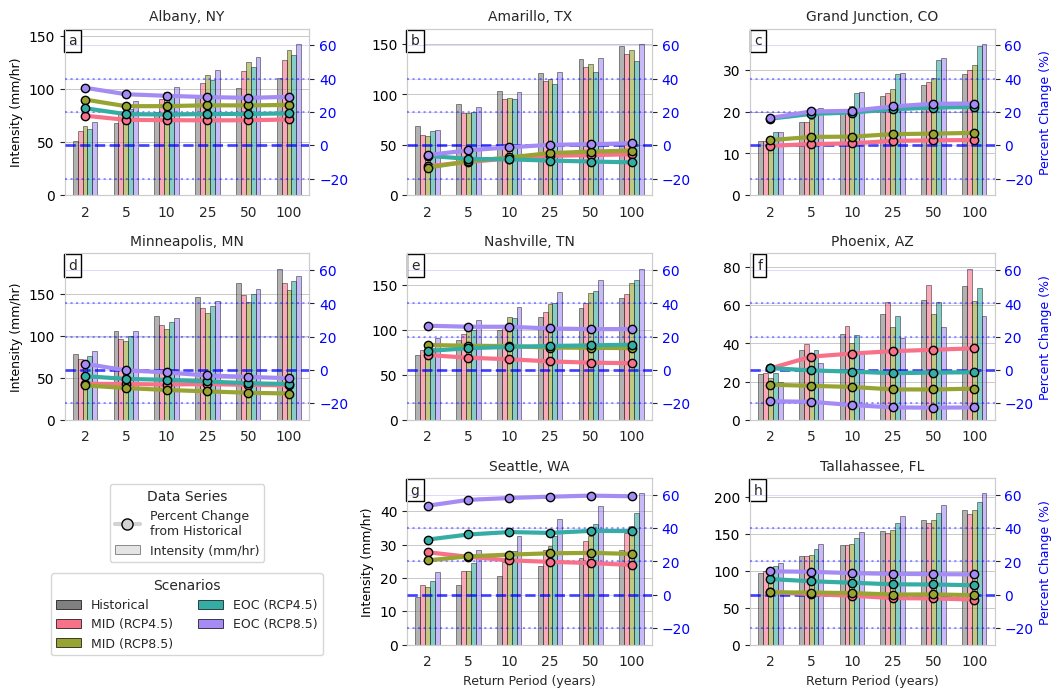

Creating enhanced departure curves for 1hr...
DEBUG: Processing 8 cities
DEBUG: Creating subplot 0 for albany
DEBUG: Creating subplot 1 for amarillo
DEBUG: Creating subplot 2 for grand_junction
DEBUG: Creating subplot 3 for minneapolis
DEBUG: Creating subplot 4 for nashville
DEBUG: Creating subplot 5 for phoenix
DEBUG: Creating subplot 6 for seattle
DEBUG: Creating subplot 7 for tallahassee


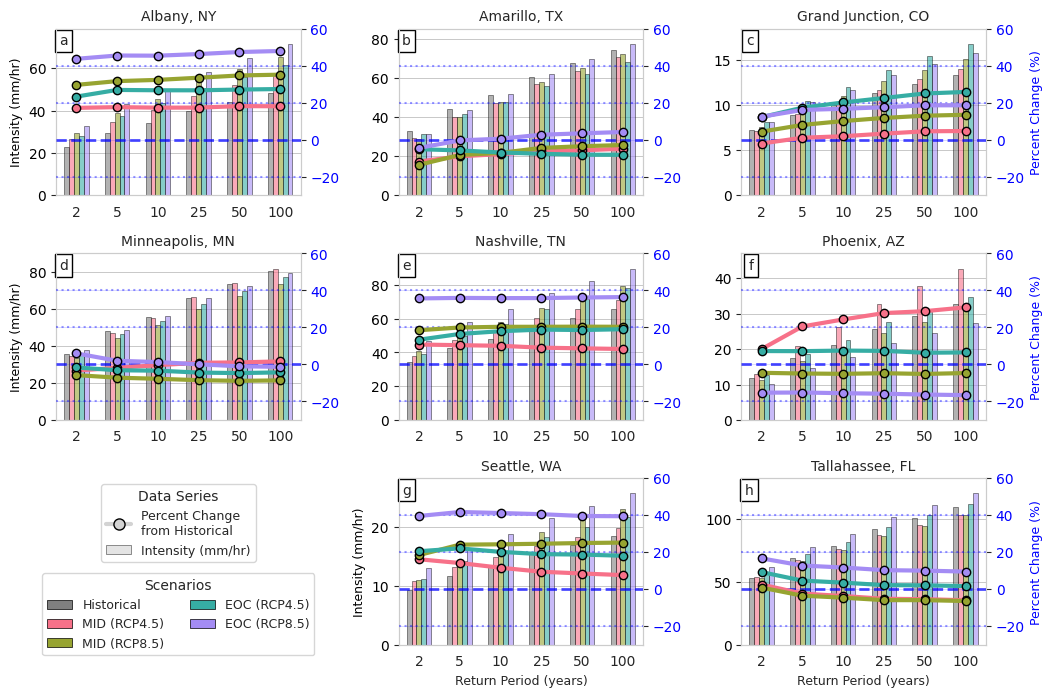

Creating enhanced departure curves for 24hr...
DEBUG: Processing 8 cities
DEBUG: Creating subplot 0 for albany
DEBUG: Creating subplot 1 for amarillo
DEBUG: Creating subplot 2 for grand_junction
DEBUG: Creating subplot 3 for minneapolis
DEBUG: Creating subplot 4 for nashville
DEBUG: Creating subplot 5 for phoenix
DEBUG: Creating subplot 6 for seattle
DEBUG: Creating subplot 7 for tallahassee


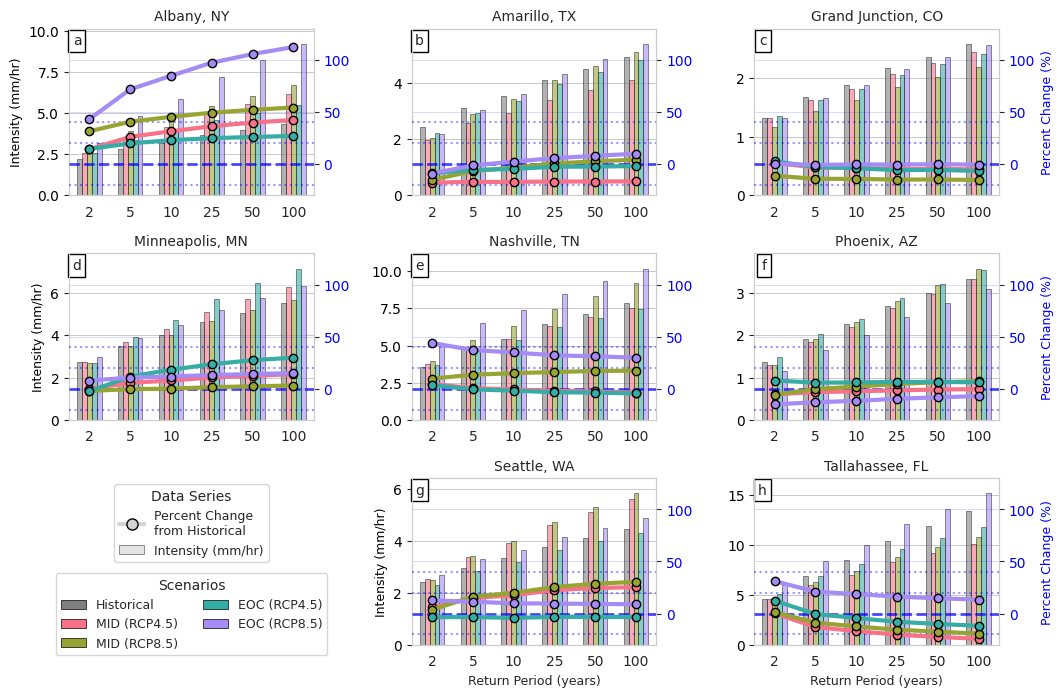

In [4]:
def format_scenario_name(scenario):
    """Convert internal scenario names to display-friendly names 
    for convience of plotting (p notation used in filenames more
    human readable for actual plot)"""
    scenario_map = {
        'eoc4p5': 'EOC (RCP4.5)',
        'eoc8p5': 'EOC (RCP8.5)', 
        'mid4p5': 'MID (RCP4.5)',
        'mid8p5': 'MID (RCP8.5)',
        'hist': 'Historical'
    }
    return scenario_map.get(scenario.lower(), scenario.upper())

def format_city_name(city):
    """Convert internal city names to display-friendly names with state abbreviations"""
    city_map = {
        'albany': 'Albany, NY',
        'amarillo': 'Amarillo, TX',
        'grand_junction': 'Grand Junction, CO',
        'minneapolis': 'Minneapolis, MN',
        'nashville': 'Nashville, TN',
        'phoenix': 'Phoenix, AZ',
        'seattle': 'Seattle, WA',
        'tallahassee': 'Tallahassee, FL',
    }
    return city_map.get(city.lower(), city.replace('_', ' ').title())

def plot_percentage_departure_curves_with_bars(pct_departures, intensities, duration='1hr', use_log_scale=True):
    """
    Enhanced plot showing percentage departure curves (lines) with absolute intensity bars (secondary axis)
    Version 3.0 - 3x3 grid with legends in lower-left subplot
    """
    
    scenarios = list(pct_departures.keys())
    # Add HIST to scenarios for bar grouping (but not for lines since lines show departures)
    all_scenarios_for_bars = ['HIST'] + scenarios
    n_scenarios = len(scenarios)
    n_bar_scenarios = len(all_scenarios_for_bars)
    
    # Create 3x3 grid
    fig = plt.figure(figsize=(12, 8)) # figsize: Width, height in inches.
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.4)
    
    # Create axes for 8 cities (skip lower-left for legend)
    axes_positions = [
        (0, 0), (0, 1), (0, 2),  # Top row
        (1, 0), (1, 1), (1, 2),  # Middle row
        (2, 1), (2, 2)           # Bottom row (skip 2,0 for legend)
    ]
    
    axes = []
    for row, col in axes_positions:
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)
    
    # Colors for scenarios - use same saturation for both lines and bars
    colors = sns.color_palette("husl", n_scenarios)
    scenario_colors = dict(zip(scenarios, colors))
    # Add gray for HIST bars
    all_bar_colors = ['gray'] + colors
    
    # Bar chart settings
    selected_return_periods = [2, 5, 10, 25, 50, 100]  # Include all return periods for bars
    bar_width = 0.12
    bar_alpha = 0.6  # Make bars semi-transparent so lines are visible
    
    # First pass: collect all percentage departure values to determine y-axis limits
    all_departures = []
    
    for city in CITIES:
        for scenario in scenarios:
            if city in pct_departures[scenario]:
                for rp in RETURN_PERIODS:
                    if rp in pct_departures[scenario][city]:
                        dep_val = pct_departures[scenario][city][rp]
                        if not np.isnan(dep_val) and not np.isinf(dep_val):
                            all_departures.append(dep_val)
    
    # Calculate shared y-axis limits with fixed bottom at -30%
    if all_departures:
        y_max = max(all_departures)
        
        # Add padding to top, fix bottom at -30
        padding = y_max * 0.1
        shared_ylim_left = (-30, y_max + padding)
        
        # Round top to nice numbers for percentage display
        shared_ylim_left = (-30, np.ceil(shared_ylim_left[1]/10)*10)
    else:
        shared_ylim_left = (-30, 10)  # Default range if no data
    
    print(f"DEBUG: Processing {len(CITIES)} cities")  # Debug print
    
    # Second pass: create plots with dual y axes
    for i, city in enumerate(CITIES):
        print(f"DEBUG: Creating subplot {i} for {city}")  # Debug print
        
        ax2 = axes[i]  # Primary axis for absolute intensity bars (left, black)
        ax1 = ax2.twinx()  # Secondary axis for departure lines (rihgt, blue)
        
        # Set up categorical x-axis positioning
        x_positions = np.arange(len(RETURN_PERIODS))  # Categorical positions: 0, 1, 2, 3, 4, 5 (for cleaner plots)
        
        #### Primary axis (left side, black) ####
        if 'HIST' in intensities and city in intensities['HIST']:
            # Get indices for selected return periods in the categorical system
            bar_positions = []
            for rp in selected_return_periods:
                if rp in RETURN_PERIODS:
                    bar_positions.append(RETURN_PERIODS.index(rp))
            
            # Process all scenarios including HIST for proper grouping
            for j, scenario in enumerate(all_scenarios_for_bars):
                if scenario in intensities and city in intensities[scenario]:
                    # Extract absolute values for selected return periods
                    scenario_values = []
                    bar_x_positions = []
                    
                    for k, rp in enumerate(selected_return_periods):
                        if rp in intensities[scenario][city]:
                            val = intensities[scenario][city][rp]
                            scenario_values.append(val if not np.isnan(val) and not np.isinf(val) else 0)
                        else:
                            scenario_values.append(0)
                        
                        # Position bars in proper group formation
                        if k < len(bar_positions):
                            categorical_pos = bar_positions[k]
                            # Offset for proper grouping with HIST included
                            offset = (j - n_bar_scenarios/2 + 0.5) * bar_width
                            bar_x_positions.append(categorical_pos + offset)
                    
                    # Create bars with consistent width and proper colors (low z-order, behind lines)
                    bars = ax2.bar(bar_x_positions, scenario_values, 
                                 width=bar_width, 
                                 color=all_bar_colors[j], alpha=bar_alpha, 
                                 edgecolor='black', linewidth=0.5, zorder=1)
        
        #### Secondary axis (right side, blue) ####
        for j, scenario in enumerate(scenarios):
            if city in pct_departures[scenario]:
                # Extract return periods and departures - use categorical positions
                deps = []
                
                # Get departure values for all return_periods in order
                for rp in RETURN_PERIODS:
                    if rp in pct_departures[scenario][city]:
                        dep_val = pct_departures[scenario][city][rp]
                        if not np.isnan(dep_val) and not np.isinf(dep_val):
                            deps.append(dep_val)
                        else:
                            deps.append(0)  # Handle missing/invalid data
                    else:
                        deps.append(0)
                
                if len(deps) > 1:  # Need at least 2 points for a line , although this *should always trigger*
                    ax1.plot(x_positions, deps, 'o-', color=scenario_colors[scenario], label=format_scenario_name(scenario), 
                             linewidth=3, markersize=6, zorder=20, markeredgecolor='black', markeredgewidth=1,
                             solid_capstyle='round', solid_joinstyle='round')
        
        #### Styling stuff ####
        # Primary axis (absolute intensity bars) styling - LEFT SIDE - BLACK
        ax2.set_title(format_city_name(city), fontsize=10)
        ax2.tick_params(axis='y', labelcolor='black')
        
        # BLACK grid lines for intensity axis (left) - HORIZONTAL ONLY
        ax2.grid(True, alpha=0.3, zorder=1, color='black', linestyle='-', linewidth=0.5, axis='y')
        
        # Secondary axis (departure lines) styling - RIGHT SIDE - BLUE
        ax1.tick_params(axis='y', labelcolor='blue')
        
        # Set shared y-axis limits for departures (right axis)
        ax1.set_ylim(shared_ylim_left)
        
        # BLUE grid lines for percent change axis (right) - HORIZONTAL ONLY
        ax1.grid(True, alpha=0.2, zorder=2, color='blue', linestyle='-', linewidth=0.5, axis='y')
        
        # Add horizontal reference lines for departure percentages (right axis) - BLUE
        ax1.axhline(y=0, color='blue', linestyle='--', alpha=0.7, zorder=15, linewidth=2)
        
        # Add horizontal reference lines at tick intervals (right axis) - BLUE
        for pct in [40, 20, -20]:
            if shared_ylim_left[0] <= pct <= shared_ylim_left[1]:
                ax1.axhline(y=pct, color='blue', linestyle=':', alpha=0.4, zorder=15)
        
        # Set x-axis scale - use categorical positioning
        ax2.set_xticks(x_positions)
        ax2.set_xticklabels([str(rp) for rp in RETURN_PERIODS])
        ax2.set_xlim(-0.5, len(RETURN_PERIODS) - 0.5)  # Add padding around categorical data
        
        # Make sure bars don't dominate the plot - set intensity y-limits
        if 'HIST' in intensities and city in intensities['HIST']:
            # Calculate reasonable y-limits for bars based on data
            all_intensities = []
            for scenario in all_scenarios_for_bars:
                if scenario in intensities and city in intensities[scenario]:
                    for rp in selected_return_periods:
                        if rp in intensities[scenario][city]:
                            val = intensities[scenario][city][rp]
                            if not np.isnan(val) and not np.isinf(val):
                                all_intensities.append(val)
            
            if all_intensities:
                bar_y_max = max(all_intensities) * 1.1
                ax2.set_ylim(0, bar_y_max)
        
        # Ensure no vertical grid lines on either axis
        # First we need to turn off all default grids (wasted time here)
        ax2.grid(False)
        ax1.grid(False)
        
        # THEN add only horizontal grid lines
        ax2.grid(True, alpha=0.3, zorder=1, color='black', linestyle='-', linewidth=0.5, axis='y')
        ax1.grid(True, alpha=0.2, zorder=2, color='blue', linestyle='-', linewidth=0.5, axis='y')
        
        # Add subplot letter in top-left corner (w/ high z-order)
        subplot_letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
        if i < len(subplot_letters):
            ax2.text(0.05, 0.97, subplot_letters[i], transform=ax2.transAxes, 
                    fontsize=10, fontweight='normal', ha='right', va='top', zorder=100,
                    bbox=dict(boxstyle='square,pad=0.3', facecolor='white', alpha=1.0, 
                             edgecolor='black', linewidth=1))
        
        # Determine position in grid
        row_idx = i // 3 if i < 6 else 2  # 0, 1, or 2
        col_idx = i % 3 if i < 6 else (i - 6) + 1  # Column position
        
        # X-axis labels: only bottom row (row 2)
        if row_idx == 2:
            ax2.set_xlabel('Return Period (years)', fontsize=9)
        
        # Left Y-axis labels: left column (col 0) and subplot g (col 1, row 2)
        if col_idx == 0 or (row_idx == 2 and col_idx == 1):
            ax2.set_ylabel('Intensity (mm/hr)', color='black', fontsize=9)
        else:
            ax2.yaxis.label.set_visible(False)
        
        # Right Y-axis labels: only right column (col 2)
        if col_idx == 2:
            ax1.set_ylabel('Percent Change (%)', color='blue', fontsize=9)
        else:
            ax1.yaxis.label.set_visible(False)
    
    # Legend in lower left
    legend_ax = fig.add_subplot(gs[2, 0])
    legend_ax.axis('off')  # Turn off axis
    
    # Create legend elements
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    
    # DATA SERIES ELEMENTS
    line_element = mlines.Line2D([0], [0], color='lightgray', linewidth=3, 
                               marker='o', markersize=8, markeredgecolor='black', 
                               markeredgewidth=1, label='Percent Change')
    
    bar_element = mpatches.Rectangle((0, 0), 1, 1, facecolor='lightgray', 
                                   edgecolor='black', linewidth=0.5, 
                                   alpha=bar_alpha, label='Intensity (mm/hr)')
    
    # SCENARIO COLOR ELEMENTS
    scenario_elements = []
    
    # Add HIST swatch
    hist_swatch = mpatches.Rectangle((0, 0), 1, 1, facecolor='gray', 
                                   edgecolor='black', linewidth=0.5, 
                                   alpha=1.0, label='HIST')
    scenario_elements.append(hist_swatch)
    
    # Add scenario swatches
    for j, scenario in enumerate(scenarios):
        swatch = mpatches.Rectangle((0, 0), 1, 1, facecolor=colors[j], 
                                  edgecolor='black', linewidth=0.5, 
                                  alpha=1.0, label=scenario)
        scenario_elements.append(swatch)
    
    # Create labels
    data_series_elements = [line_element, bar_element]
    data_series_labels = ['Percent Change\nfrom Historical', 'Intensity (mm/hr)']
    
    scenario_labels = [format_scenario_name('HIST')] + [format_scenario_name(s) for s in scenarios]
    
    # Place legends in the lower-left subplot
    # Data series legend (top of subplot)
    legend1 = legend_ax.legend(handles=data_series_elements, 
                              labels=data_series_labels,
                              title="Data Series",
                              loc='upper center', 
                              bbox_to_anchor=(0.5, 1.0),
                              ncol=1, fontsize=9, frameon=True,
                              title_fontsize=10)
    
    # Scenarios legend (bottom of subplot, 2 columns to save space)
    legend2 = legend_ax.legend(handles=scenario_elements, 
                              labels=scenario_labels,
                              title="Scenarios",
                              loc='lower center',
                              bbox_to_anchor=(0.5, -0.10),
                              ncol=2, fontsize=9, frameon=True,
                              title_fontsize=10)
    
    # Add the first legend back (matplotlib removes it when creating the second)
    legend_ax.add_artist(legend1)
    
    # Overall title
    #fig.suptitle(f'Extreme Precipitation Intensity Changes\n{duration} Duration Events', 
    #             fontsize=12, y=0.98)
    
    return fig

# Driver code
def create_enhanced_departure_curves():
    """
    Create enhanced departure curves with dual-axis bar charts
    Version 3.0 - 3x3 grid layout
    """
    
    for duration in DURATIONS:
        print(f"Creating enhanced departure curves for {duration}...")
        
        # Extract intensities and calculate departures (your existing functions)
        intensities = extract_intensities(idf_data, duration)
        abs_deps, pct_deps = calculate_departures(intensities)
        
        # Create enhanced plot
        fig_enhanced = plot_percentage_departure_curves_with_bars(pct_deps, intensities, duration)
        fig_enhanced.savefig(f'idf_enhanced_departure_curves_{duration}_horz.png', dpi=300, bbox_inches='tight')
        plt.show(fig_enhanced)
        
        plt.close('all')  # Clean up memory

create_enhanced_departure_curves()

In [5]:
# Cell 5: Extract intensities across ALL durations for a fixed return period,
# plus HIST metropolitan bootstrap envelope (as % of HIST median)
# Uses ensemble_lower / ensemble_median / ensemble_upper directly from the netCDFs

ALL_DURATIONS = ['15min', '30min', '1hr', '2hr', '3hr', '6hr', '12hr', '24hr']
DURATION_HOURS = {'15min': 0.25, '30min': 0.5, '1hr': 1.0, '2hr': 2.0,
                  '3hr': 3.0, '6hr': 6.0, '12hr': 12.0, '24hr': 24.0}

def extract_intensities_by_duration(data, return_period=25, durations=ALL_DURATIONS):
    """results[scenario][city][duration] = ensemble_median intensity (mm/hr)"""
    results = {}
    
    for scenario in data:
        results[scenario] = {}
        
        for city in data[scenario]:
            ds = data[scenario][city]
            
            rp_values = [int(rp) for rp in ds.return_period.values]
            if return_period not in rp_values:
                print(f" RP {return_period} not found for {scenario}/{city}")
                continue
            rp_idx = rp_values.index(return_period)
            
            duration_labels = list(ds.duration_label.values)
            city_data = {}
            for duration in durations:
                if duration in duration_labels:
                    dur_idx = duration_labels.index(duration)
                    city_data[duration] = ds.ensemble_median[rp_idx, dur_idx].values.item()
            
            results[scenario][city] = city_data
    
    return results

def extract_hist_ci_envelope(data, return_period=25, durations=ALL_DURATIONS):
    """HIST bootstrap 95% CI envelope for the change-vs-duration figure.
    Same recipe as Tables S1-S3: per-cell CI half-width (upper - lower)/2,
    expressed as percent of that cell's point estimate, then median across
    the 441 grid cells. Symmetric band: returns (-pct, +pct)."""
    envelope = {}
    
    for city in data['HIST']:
        ds = data['HIST'][city]
        
        rp_values = [int(rp) for rp in ds.return_period.values]
        if return_period not in rp_values:
            continue
        rp_idx = rp_values.index(return_period)
        
        lat_dim = ds.attrs.get('lat_dim', 'south_north')
        lon_dim = ds.attrs.get('lon_dim', 'west_east')
        
        duration_labels = list(ds.duration_label.values)
        city_env = {}
        for duration in durations:
            if duration in duration_labels:
                dur_idx = duration_labels.index(duration)
                
                point = ds.cell_intensity[:, :, rp_idx, dur_idx]
                half_width_pct = (
                    (ds.cell_ci_upper[:, :, rp_idx, dur_idx]
                     - ds.cell_ci_lower[:, :, rp_idx, dur_idx]) / 2
                    / point * 100
                ).median(dim=[lat_dim, lon_dim], skipna=True).values.item()
                
                city_env[duration] = (-half_width_pct, half_width_pct)
        
        envelope[city] = city_env
    
    return envelope

def calculate_departures_by_duration(results, baseline='HIST'):
    """pct_departures[scenario][city][duration]"""
    pct_departures = {}
    
    for scenario in results:
        if scenario == baseline:
            continue
        
        pct_departures[scenario] = {}
        
        for city in results[scenario]:
            if city in results[baseline]:
                pct_departures[scenario][city] = {}
                
                for duration in results[scenario][city]:
                    if duration in results[baseline][city]:
                        baseline_val = results[baseline][city][duration]
                        scenario_val = results[scenario][city][duration]
                        
                        if baseline_val != 0:
                            pct_departures[scenario][city][duration] = \
                                ((scenario_val - baseline_val) / baseline_val) * 100
                        else:
                            pct_departures[scenario][city][duration] = np.nan
    
    return pct_departures

Creating change-vs-duration figure for 25-yr return period...


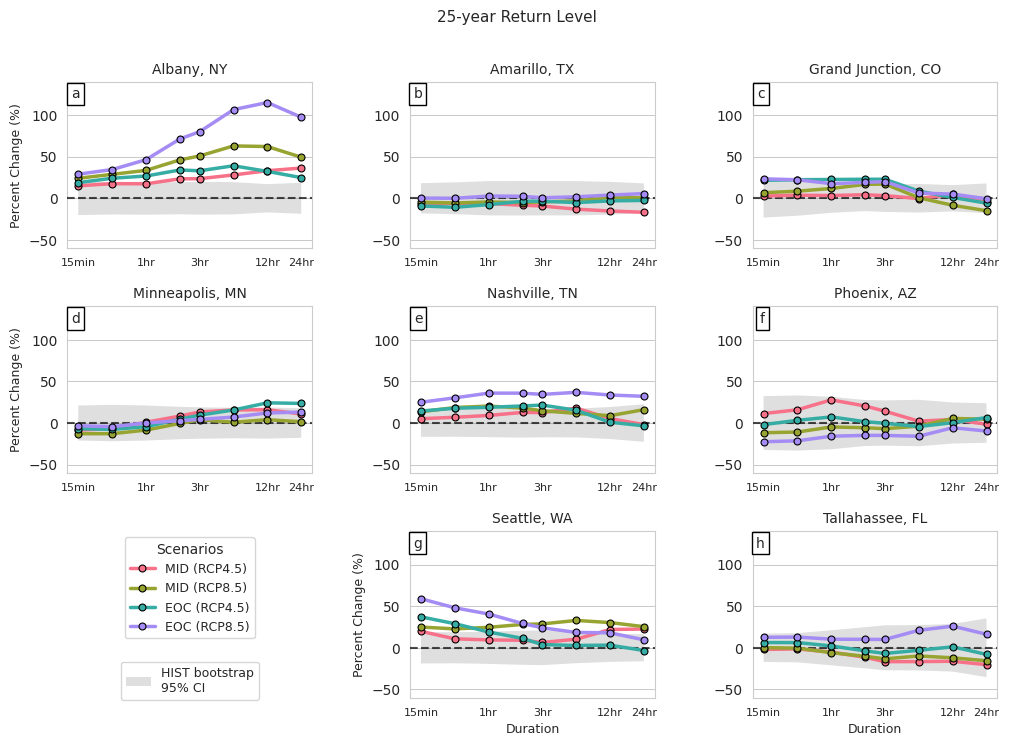

In [6]:
# Percent change vs duration (log x-axis, all 8 durations)
# Lines = 4 future scenarios; grey band = HIST bootstrap sampling envelope

def plot_change_vs_duration(pct_departures, hist_envelope=None, return_period=25,
                            durations=ALL_DURATIONS):
    
    scenarios = list(pct_departures.keys())
    n_scenarios = len(scenarios)
    
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.4)
    
    axes_positions = [
        (0, 0), (0, 1), (0, 2),
        (1, 0), (1, 1), (1, 2),
        (2, 1), (2, 2)
    ]
    
    axes = []
    for row, col in axes_positions:
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)
    
    colors = sns.color_palette("husl", n_scenarios)
    scenario_colors = dict(zip(scenarios, colors))
    
    x_hours = [DURATION_HOURS[d] for d in durations]
    
    # Shared y-limits (data + envelope)
    all_vals = []
    for scenario in scenarios:
        for city in CITIES:
            if city in pct_departures[scenario]:
                for duration in durations:
                    v = pct_departures[scenario][city].get(duration, np.nan)
                    if not np.isnan(v) and not np.isinf(v):
                        all_vals.append(v)
    if hist_envelope is not None:
        for city in hist_envelope:
            for duration in hist_envelope[city]:
                lo, hi = hist_envelope[city][duration]
                if not np.isnan(lo): all_vals.append(lo)
                if not np.isnan(hi): all_vals.append(hi)
    
    if all_vals:
        y_min, y_max = min(all_vals), max(all_vals)
        pad = (y_max - y_min) * 0.1
        shared_ylim = (np.floor((y_min - pad)/10)*10, np.ceil((y_max + pad)/10)*10)
    else:
        shared_ylim = (-30, 50)
    
    # Tick subset to avoid label crowding on log axis
    tick_durations = ['15min', '1hr', '3hr', '12hr', '24hr']
    tick_hours = [DURATION_HOURS[d] for d in tick_durations]
    
    for i, city in enumerate(CITIES):
        ax = axes[i]
        
        # HIST sampling envelope
        if hist_envelope is not None and city in hist_envelope:
            lowers = [hist_envelope[city].get(d, (np.nan, np.nan))[0] for d in durations]
            uppers = [hist_envelope[city].get(d, (np.nan, np.nan))[1] for d in durations]
            ax.fill_between(x_hours, lowers, uppers,
                            color='gray', alpha=0.25, zorder=2, edgecolor='none')
        
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.7,
                   zorder=5, linewidth=1.5)
        
        for j, scenario in enumerate(scenarios):
            if city in pct_departures[scenario]:
                deps = []
                for duration in durations:
                    v = pct_departures[scenario][city].get(duration, np.nan)
                    deps.append(v if not np.isnan(v) and not np.isinf(v) else np.nan)
                
                ax.plot(x_hours, deps, 'o-',
                        color=scenario_colors[scenario],
                        label=format_scenario_name(scenario),
                        linewidth=2.5, markersize=5, zorder=20,
                        markeredgecolor='black', markeredgewidth=0.8,
                        solid_capstyle='round', solid_joinstyle='round')
        
        #### Styling ####
        ax.set_title(format_city_name(city), fontsize=10)
        ax.set_xscale('log')
        ax.set_ylim(shared_ylim)
        ax.set_xlim(x_hours[0]*0.8, x_hours[-1]*1.25)
        
        ax.set_xticks(tick_hours)
        ax.set_xticklabels(tick_durations, fontsize=8)
        ax.minorticks_off()
        
        ax.grid(False)
        ax.grid(True, alpha=0.3, zorder=1, color='black',
                linestyle='-', linewidth=0.5, axis='y')
        
        subplot_letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
        ax.text(0.05, 0.97, subplot_letters[i], transform=ax.transAxes,
                fontsize=10, fontweight='normal', ha='right', va='top', zorder=100,
                bbox=dict(boxstyle='square,pad=0.3', facecolor='white', alpha=1.0,
                          edgecolor='black', linewidth=1))
        
        row_idx = i // 3 if i < 6 else 2
        col_idx = i % 3 if i < 6 else (i - 6) + 1
        
        if row_idx == 2:
            ax.set_xlabel('Duration', fontsize=9)
        if col_idx == 0 or (row_idx == 2 and col_idx == 1):
            ax.set_ylabel('Percent Change (%)', fontsize=9)
    
    # Legend in lower-left slot
    legend_ax = fig.add_subplot(gs[2, 0])
    legend_ax.axis('off')
    
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    
    scenario_elements = [
        mlines.Line2D([0], [0], color=colors[j], linewidth=2.5,
                      marker='o', markersize=5, markeredgecolor='black',
                      markeredgewidth=0.8, label=format_scenario_name(s))
        for j, s in enumerate(scenarios)
    ]
    band_element = mpatches.Rectangle((0, 0), 1, 1, facecolor='gray',
                                      alpha=0.25, edgecolor='none',
                                      label='HIST bootstrap\n95% CI')
    
    legend1 = legend_ax.legend(handles=scenario_elements, title="Scenarios",
                               loc='upper center', bbox_to_anchor=(0.5, 1.0),
                               ncol=1, fontsize=9, frameon=True, title_fontsize=10)
    legend2 = legend_ax.legend(handles=[band_element],
                               loc='lower center', bbox_to_anchor=(0.5, -0.05),
                               ncol=1, fontsize=9, frameon=True)
    legend_ax.add_artist(legend1)
    
    fig.text(0.5, 0.955, f'{return_period}-year Return Level',
             ha='center', fontsize=11)
    
    return fig

# Driver function for plotting
def create_change_vs_duration_figures(return_periods_to_plot=[25]):
    for rp in return_periods_to_plot:
        print(f"Creating change-vs-duration figure for {rp}-yr return period...")
        
        intensities_dur = extract_intensities_by_duration(idf_data, return_period=rp)
        pct_deps_dur = calculate_departures_by_duration(intensities_dur)
        hist_env = extract_hist_ci_envelope(idf_data, return_period=rp)
        
        fig = plot_change_vs_duration(pct_deps_dur, hist_env, return_period=rp)
        fig.savefig(f'change_vs_duration_rp{rp}_{VERSION_TAG}.png',
                    dpi=300, bbox_inches='tight')
        fig.savefig(f'change_vs_duration_rp{rp}_{VERSION_TAG}.pdf',
                    bbox_inches='tight')
        plt.show(fig)
        plt.close('all')

create_change_vs_duration_figures(return_periods_to_plot=[25])
# Supplement / RP sensitivity:
# create_change_vs_duration_figures(return_periods_to_plot=[2, 10, 100])

In [7]:
env = extract_hist_ci_envelope(idf_data, return_period=25)
for d in ALL_DURATIONS:
    lo, hi = env['albany'][d]
    print(f"albany {d:>6}: ({lo:+.1f}, {hi:+.1f})")

albany  15min: (-20.2, +20.2)
albany  30min: (-19.5, +19.5)
albany    1hr: (-19.8, +19.8)
albany    2hr: (-19.2, +19.2)
albany    3hr: (-19.7, +19.7)
albany    6hr: (-19.4, +19.4)
albany   12hr: (-17.0, +17.0)
albany   24hr: (-18.6, +18.6)
